<a href="https://colab.research.google.com/github/RadRebelSam/ai4all-20c-darkpatterns/blob/main/AI4ALL_20C_Dark_Pattern_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dark Pattern Recognition: Colab Model Training

This notebook trains and evaluates the AI4ALL Ignite Team 20C dark-pattern models.

It now includes both trained models used by the project:

- **Model 1:** binary `Dark Pattern` vs `Not Dark Pattern` detector.
- **Model 2:** second-stage category/type classifier for suspicious text.

Run the cells from top to bottom. CPU runtime is enough; no GPU is required.


## 0. remove previously imported GitHub repo in Google Colab

In [ ]:
import shutil
from pathlib import Path

repo_path = Path("/content/ai4all-20c-darkpatterns")
if repo_path.exists():
    shutil.rmtree(repo_path)
    print("Removed old repo folder")
else:
    print("No old repo folder found")


FileNotFoundError: [Errno 2] No such file or directory: '/content/ai4all-20c-darkpatterns'

## 1. Clone the GitHub project

This downloads the repo into Colab so the notebook can use the same `src/`, `scripts/`, and `datasets/` folders as the project.

In [ ]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/RadRebelSam/ai4all-20c-darkpatterns.git"
PROJECT_DIR = Path("/content/ai4all-20c-darkpatterns")

if not PROJECT_DIR.exists():
    !git clone {REPO_URL} {PROJECT_DIR}
else:
    print(f"Project already exists at {PROJECT_DIR}")

os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))
print("Current folder:", Path.cwd())

Project already exists at /content/ai4all-20c-darkpatterns
Current folder: /content/ai4all-20c-darkpatterns


## 2. Install packages

The project uses `pandas`, `scikit-learn`, `joblib`, `matplotlib`, and `seaborn`.

In [ ]:
!pip install -q -r requirements.txt seaborn openpyxl

## 3. Check dataset files

If any file says `MISSING`, upload that dataset into the `datasets/` folder in Colab.

In [ ]:
expected_files = [
    "krishuppal - dark-patterns.csv",
    "devitachi - dark-pattern.csv",
    "- pattern_classifications.csv",
    "adarshm09 - dark-pattern-dataset.csv",
    "mohitsharma527 - dark-patterns-on-ecommerce-platforms.csv",
]

for filename in expected_files:
    path = Path("datasets") / filename
    print(("FOUND   " if path.exists() else "MISSING ") + str(path))

FOUND   datasets/krishuppal - dark-patterns.csv
FOUND   datasets/devitachi - dark-pattern.csv
FOUND   datasets/- pattern_classifications.csv
FOUND   datasets/adarshm09 - dark-pattern-dataset.csv
FOUND   datasets/mohitsharma527 - dark-patterns-on-ecommerce-platforms.csv


## 4. Load primary and expanded datasets

The project normalizes different dataset columns into one shared schema:

- `text`
- `label`
- `category`
- `source`

In [ ]:
import pandas as pd

from src.data import (
    TEXT_COLUMN,
    LABEL_COLUMN,
    CATEGORY_COLUMN,
    SOURCE_COLUMN,
    load_primary_binary_dataset,
    load_expanded_binary_dataset,
    load_dark_pattern_category_dataset,
    summarize_labels,
    validate_binary_dataset,
    validate_category_dataset,
)

primary_df = load_primary_binary_dataset()
expanded_df = load_expanded_binary_dataset()
category_df = load_dark_pattern_category_dataset()

validate_binary_dataset(primary_df)
validate_binary_dataset(expanded_df)
validate_category_dataset(category_df)

print("Primary binary rows:", len(primary_df))
print("Primary label counts:", summarize_labels(primary_df))
print()
print("Expanded binary rows:", len(expanded_df))
print("Expanded label counts:", summarize_labels(expanded_df))
print("Expanded source counts:")
print(expanded_df[SOURCE_COLUMN].value_counts())
print()
print("Second-stage category rows:", len(category_df))
print("Category counts:")
print(category_df[CATEGORY_COLUMN].value_counts().sort_index())

display(primary_df.head())


Primary rows: 2356
Primary label counts: {'0': 1178, '1': 1178}

Expanded rows: 4151
Expanded label counts: {'0': 2616, '1': 1535}
Expanded source counts:
source
akashnath29                1802
devitachi; krishuppal      1178
krishuppal                 1158
akashnath29; krishuppal      13
Name: count, dtype: int64


,text,label,category,source
0,FLASH SALE | LIMITED TIME ONLY Shop Now,1,Urgency,krishuppal
1,Pillowcases & Shams,0,Not Dark Pattern,krishuppal
2,Write a review,0,Not Dark Pattern,krishuppal
3,"To start your return, simply click on the foll...",0,Not Dark Pattern,krishuppal
4,newsletter signup (privacy policy),0,Not Dark Pattern,krishuppal


## 5. Visualize dataset balance

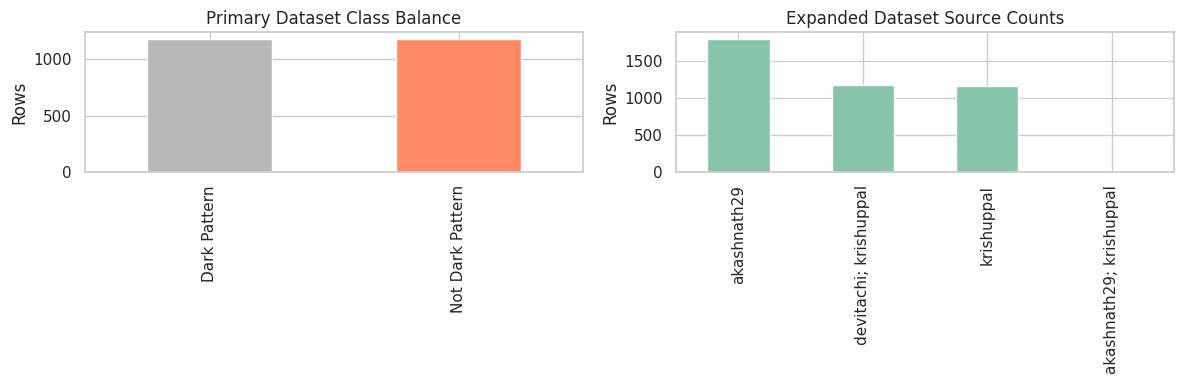

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

primary_df[LABEL_COLUMN].map({0: "Not Dark Pattern", 1: "Dark Pattern"}).value_counts().plot(
    kind="bar",
    ax=axes[0],
    color=["#b8b8b8", "#ff8a65"],
)
axes[0].set_title("Primary Dataset Class Balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")

expanded_df[SOURCE_COLUMN].value_counts().plot(kind="bar", ax=axes[1], color="#86c5a9")
axes[1].set_title("Expanded Dataset Source Counts")
axes[1].set_xlabel("")
axes[1].set_ylabel("Rows")

plt.tight_layout()
plt.show()

## 6. Train and compare models

Each model uses the same TF-IDF text representation. TF-IDF is not the prediction model itself; it converts text into numeric features that the classifiers can learn from.

The tested classifiers are Logistic Regression, Naive Bayes, Linear SVM, Decision Tree, and Random Forest.

In [ ]:
from src.modeling import (
    train_and_compare,
    train_and_compare_categories,
    results_to_frame,
    category_results_to_frame,
)

primary_results = train_and_compare(primary_df)
primary_metrics = results_to_frame(primary_results)

expanded_results = train_and_compare(expanded_df)
expanded_metrics = results_to_frame(expanded_results)

category_results = train_and_compare_categories(category_df)
category_metrics = category_results_to_frame(category_results)

print("Primary binary dataset results")
display(primary_metrics)
print("Expanded binary dataset results")
display(expanded_metrics)
print("Second-stage category model results")
display(category_metrics)

best_primary = primary_results[0]
best_category = category_results[0]
print("Best primary binary model:", best_primary.name)
print("Best second-stage category model:", best_category.name)


Primary dataset results


,model,accuracy,precision,recall,f1
0,Logistic Regression,0.938559,0.972603,0.902542,0.936264
1,Linear SVM,0.932203,0.959459,0.902542,0.930131
2,Naive Bayes,0.927966,0.927966,0.927966,0.927966
3,Random Forest,0.927966,0.985577,0.868644,0.923423
4,Decision Tree,0.917373,0.980488,0.851695,0.911565


Expanded dataset results


,model,accuracy,precision,recall,f1
0,Linear SVM,0.904934,0.870130,0.872964,0.871545
1,Logistic Regression,0.897714,0.926923,0.785016,0.850088
2,Naive Bayes,0.885680,0.858108,0.827362,0.842454
3,Decision Tree,0.888087,0.921260,0.762215,0.834225
4,Random Forest,0.890493,0.969565,0.726384,0.830540


Best primary model: Logistic Regression


## 7. Plot model comparison by F1 score

F1 score balances precision and recall.

- Precision: when the model says something is a dark pattern, how often is it correct?
- Recall: of all real dark patterns, how many did the model catch?

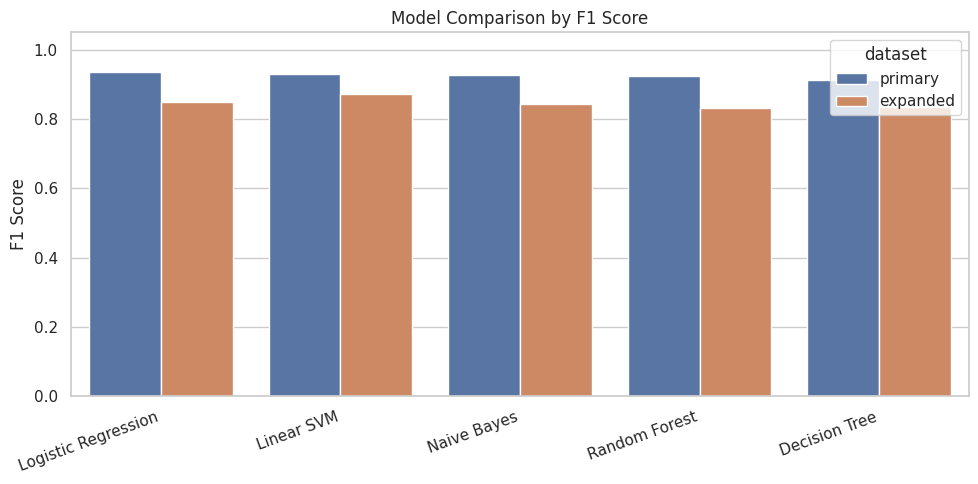

In [ ]:
comparison = primary_metrics.copy()
comparison["dataset"] = "primary"

expanded_comparison = expanded_metrics.copy()
expanded_comparison["dataset"] = "expanded"

comparison = pd.concat([comparison, expanded_comparison], ignore_index=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison, x="model", y="f1", hue="dataset")
plt.title("Model Comparison by F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 7B. Visualize the two-model pipeline

The final project uses two trained models: first a binary detector, then a category classifier only if the text looks suspicious.

In [ ]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.axis("off")

boxes = [
    (0.04, 0.52, 0.22, 0.28, "Website text", "Snippet from app or webpage scan"),
    (0.34, 0.52, 0.24, 0.28, "Model 1", "Binary detector\nDark vs Not Dark"),
    (0.68, 0.62, 0.26, 0.22, "Not Dark", "Stop here"),
    (0.68, 0.28, 0.26, 0.24, "Model 2", "Likely type\nUrgency, Scarcity, etc."),
]
for x, y, w, h, title, body in boxes:
    patch = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.03", facecolor="#e8f3ff", edgecolor="#263238")
    ax.add_patch(patch)
    ax.text(x + w/2, y + h*0.65, title, ha="center", va="center", fontsize=14, fontweight="bold")
    ax.text(x + w/2, y + h*0.35, body, ha="center", va="center", fontsize=10)

arrow = dict(arrowstyle="->", lw=2, color="#263238")
ax.annotate("", xy=(0.34, 0.66), xytext=(0.26, 0.66), arrowprops=arrow)
ax.annotate("", xy=(0.68, 0.73), xytext=(0.58, 0.67), arrowprops=arrow)
ax.annotate("", xy=(0.68, 0.41), xytext=(0.58, 0.58), arrowprops=arrow)
ax.text(0.60, 0.76, "if not suspicious", fontsize=9)
ax.text(0.60, 0.46, "if suspicious", fontsize=9)
plt.title("Two-Stage Dark Pattern Recognition Pipeline", fontsize=16, fontweight="bold")
plt.show()


## 7C. Category model comparison

The category model is evaluated with macro metrics because the dark-pattern categories are imbalanced.

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=category_metrics, x="model", y="f1_macro", color="#6fbf73")
plt.title("Second-Stage Category Model Comparison by Macro F1")
plt.ylabel("Macro F1")
plt.xlabel("")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 7D. Category confusion matrix and per-class F1

These charts show which dark-pattern types the second model handles well and which categories are harder.

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

x_cat_train, x_cat_test, y_cat_train, y_cat_test = train_test_split(
    category_df[TEXT_COLUMN],
    category_df[CATEGORY_COLUMN],
    test_size=0.2,
    stratify=category_df[CATEGORY_COLUMN],
    random_state=42,
)

category_pipeline = best_category.pipeline
cat_predictions = category_pipeline.predict(x_cat_test)
labels = sorted(y_cat_test.unique())

ConfusionMatrixDisplay.from_predictions(
    y_cat_test,
    cat_predictions,
    display_labels=labels,
    cmap="Blues",
    xticks_rotation=35,
)
plt.title("Category Confusion Matrix: Linear SVM")
plt.tight_layout()
plt.show()

precision, recall, f1, support = precision_recall_fscore_support(
    y_cat_test,
    cat_predictions,
    labels=labels,
    zero_division=0,
)
per_class = pd.DataFrame({
    "category": labels,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support,
}).sort_values("f1")

display(per_class)

plt.figure(figsize=(9, 5))
sns.barplot(data=per_class, x="f1", y="category", color="#4ea5d9")
plt.title("Second-Stage Model F1 by Dark Pattern Type")
plt.xlabel("F1 Score")
plt.ylabel("")
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()


## 8. Confusion matrix for Logistic Regression

Logistic Regression is the project default because it performs strongly, trains quickly, is interpretable, and provides confidence scores through `predict_proba`.

                  precision    recall  f1-score   support

Not Dark Pattern       0.91      0.97      0.94       236
    Dark Pattern       0.97      0.90      0.94       236

        accuracy                           0.94       472
       macro avg       0.94      0.94      0.94       472
    weighted avg       0.94      0.94      0.94       472



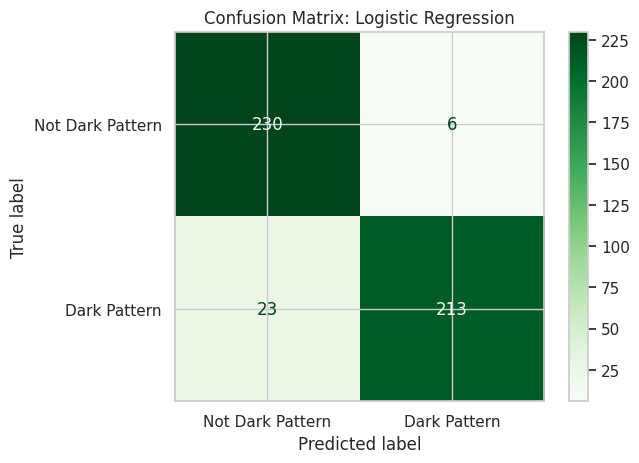

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from src.modeling import make_pipeline, split_dataset

x_train, x_test, y_train, y_test = split_dataset(primary_df)

default_model_name = "Logistic Regression"
default_pipeline = make_pipeline(default_model_name)
default_pipeline.fit(x_train, y_train)

predictions = default_pipeline.predict(x_test)

print(classification_report(y_test, predictions, target_names=["Not Dark Pattern", "Dark Pattern"]))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Not Dark Pattern", "Dark Pattern"],
    cmap="Greens",
)
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

## 9. Inspect top TF-IDF features

This shows which words or phrases push Logistic Regression toward `Dark Pattern` or `Not Dark Pattern`.

In [ ]:
import numpy as np

tfidf = default_pipeline.named_steps["tfidf"]
classifier = default_pipeline.named_steps["classifier"]

feature_names = np.array(tfidf.get_feature_names_out())
coefficients = classifier.coef_[0]

top_dark_idx = np.argsort(coefficients)[-15:][::-1]
top_not_dark_idx = np.argsort(coefficients)[:15]

top_features = pd.DataFrame({
    "dark_pattern_terms": feature_names[top_dark_idx],
    "dark_pattern_weight": coefficients[top_dark_idx],
    "not_dark_pattern_terms": feature_names[top_not_dark_idx],
    "not_dark_pattern_weight": coefficients[top_not_dark_idx],
})

display(top_features)

,dark_pattern_terms,dark_pattern_weight,not_dark_pattern_terms,not_dark_pattern_weight
0,left,5.767759,view,-1.237697
1,purchased,3.737782,remotes,-1.220046
2,bought,3.656235,shop,-1.137304
3,thanks,3.618680,accessories,-1.050464
4,people,3.575873,cookies,-0.944985
5,limited,3.113568,new,-0.809168
6,stock,3.084004,great,-0.778048
7,time,2.692160,collection,-0.758007
8,hurry,2.647479,read,-0.753881
9,minutes,2.384579,clothing,-0.734242


## 10. Try custom predictions with both models

If Model 1 predicts `Dark Pattern`, Model 2 adds a likely category/type.


In [ ]:
examples = [
    "Only 2 left in stock. Buy now before it is gone.",
    "Free shipping on orders over $50.",
    "500 people are viewing this deal right now.",
    "Cotton t-shirt with crew neck and short sleeves.",
    "Limited time offer ends in 10 minutes.",
]

probabilities = default_pipeline.predict_proba(examples)
predicted_labels = default_pipeline.predict(examples)

rows = []
for text, label, probs in zip(examples, predicted_labels, probabilities):
    row = {
        "text": text,
        "prediction": "Dark Pattern" if label == 1 else "Not Dark Pattern",
        "confidence": round(float(probs[label]), 4),
        "likely_type": "Not applicable",
    }
    if label == 1:
        row["likely_type"] = category_pipeline.predict([text])[0]
    rows.append(row)

display(pd.DataFrame(rows))


,text,prediction,confidence
0,Only 2 left in stock. Buy now before it is gone.,Dark Pattern,0.8780
1,Free shipping on orders over $50.,Not Dark Pattern,0.5700
2,500 people are viewing this deal right now.,Dark Pattern,0.8556
3,Cotton t-shirt with crew neck and short sleeves.,Not Dark Pattern,0.8613
4,Limited time offer ends in 10 minutes.,Dark Pattern,0.9889


## 11. Save metrics and trained model

These files can be downloaded from the Colab file browser.

In [ ]:
import joblib

Path("reports").mkdir(exist_ok=True)
Path("artifacts").mkdir(exist_ok=True)

primary_metrics.to_csv("reports/colab_primary_model_metrics.csv", index=False)
expanded_metrics.to_csv("reports/colab_expanded_model_metrics.csv", index=False)
category_metrics.to_csv("reports/colab_category_model_metrics.csv", index=False)
joblib.dump(default_pipeline, "artifacts/colab_logistic_regression_model.joblib")
joblib.dump(category_pipeline, "artifacts/colab_category_model.joblib")

print("Saved reports/colab_primary_model_metrics.csv")
print("Saved reports/colab_expanded_model_metrics.csv")
print("Saved reports/colab_category_model_metrics.csv")
print("Saved artifacts/colab_logistic_regression_model.joblib")
print("Saved artifacts/colab_category_model.joblib")


Saved reports/colab_primary_model_metrics.csv
Saved reports/colab_expanded_model_metrics.csv
Saved artifacts/colab_logistic_regression_model.joblib


## 12. Download outputs

Run this cell if you want Colab to download the metrics and trained model to your computer.

In [ ]:
from google.colab import files

files.download("reports/colab_primary_model_metrics.csv")
files.download("reports/colab_expanded_model_metrics.csv")
files.download("reports/colab_category_model_metrics.csv")
files.download("artifacts/colab_logistic_regression_model.joblib")
files.download("artifacts/colab_category_model.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>